# 02_config_diagonal_dirac_mixture

- Diagonal covariance with multimodal finite atomic eigenvalue law.
- Config: `configs/config_diagonal_dirac_mixture.yaml`
- Workflow: simulate -> realized covariance spectrum -> MP inverse -> recovery metrics.


In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (
        p
        for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'mpdiff').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root (expected pyproject.toml and src/mpdiff).')
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from mpdiff.config.loader import load_config
from mpdiff.experiments.run_end_to_end import run_end_to_end

config_path = PROJECT_ROOT / 'configs/config_diagonal_dirac_mixture.yaml'
cfg = load_config(config_path)
out_dir = Path(cfg.global_settings.output_dir)
out_dir


PosixPath('outputs/config_diagonal_dirac_mixture')

In [10]:
summary = run_end_to_end(config_path)
summary


2026-04-09 08:51:58,148 | INFO | mpdiff.experiments.run_full_pipeline | build_schedule completed in 0.087s
2026-04-09 08:51:59,201 | INFO | mpdiff.experiments.run_full_pipeline | Simulated diffusion: d=100, steps=10000, horizon=1.000000
2026-04-09 08:51:59,202 | INFO | mpdiff.experiments.run_full_pipeline | simulation completed in 1.054s
2026-04-09 08:51:59,209 | INFO | mpdiff.experiments.run_full_pipeline | compute_increments completed in 0.006s
2026-04-09 08:51:59,212 | INFO | mpdiff.experiments.run_full_pipeline | realized_covariance completed in 0.002s
2026-04-09 08:51:59,214 | INFO | mpdiff.experiments.run_full_pipeline | eigendecomposition completed in 0.001s
2026-04-09 08:51:59,218 | INFO | mpdiff.experiments.run_full_pipeline | empirical_density_estimation completed in 0.000s
2026-04-09 08:53:03,946 | INFO | mpdiff.experiments.run_full_pipeline | mp_inverse completed in 64.727s
2026-04-09 08:53:04,060 | INFO | mpdiff.experiments.run_full_pipeline | reference_population complete

{'method': 'optimization',
 'aspect_ratio': 0.01,
 'reference_population_mean': 1.3160000000999996,
 'estimated_population_mean': 1.5130534768973967,
 'population_wasserstein_1': 0.2033801428034936,
 'reconstruction_l2': 0.23113665604503664,
 'output_dir': 'outputs/config_diagonal_dirac_mixture'}

In [11]:
summary_csv = out_dir / 'full_pipeline_method_summary.csv'
meta_json = out_dir / 'full_pipeline_metadata.json'
report_txt = out_dir / 'full_pipeline_report.txt'

df = pd.read_csv(summary_csv)
display(df)

meta = json.loads(meta_json.read_text())
print('timers (seconds):')
for k, v in meta['timers_seconds'].items():
    print(f'  {k}: {v:.4f}')

print('\nreport preview:')
print(report_txt.read_text()[:1600])


,method,estimated_population_mean,population_l1,population_l2,population_wasserstein_1,population_support_min_diff,population_support_max_diff,population_moment1_abs_error,population_moment2_abs_error,population_moment3_abs_error,reconstruction_l1,reconstruction_l2,reconstruction_wasserstein_1
0,fixed_point,1.357925,0.591977,0.427040,0.077837,0.0,0.450867,0.046945,0.163704,0.471332,0.055064,0.052638,0.016738
1,stieltjes_based,1.336935,0.667618,0.464143,0.085372,0.0,0.254335,0.025109,0.063798,0.123134,0.217832,0.189877,0.027506
2,moment_based,1.338908,0.762038,0.516233,0.125948,0.0,1.179191,0.024759,0.102674,0.545106,0.287656,0.203742,0.091590
3,optimization,1.513053,0.734642,0.479899,0.203380,0.0,1.248555,0.202110,0.666361,2.076863,0.291325,0.231137,0.174083


timers (seconds):
  build_schedule: 0.0870
  compute_increments: 0.0056
  eigendecomposition: 0.0008
  empirical_density_estimation: 0.0004
  mp_inverse: 64.7268
  realized_covariance: 0.0024
  reference_population: 0.1132
  simulation: 1.0536

report preview:
mpdiff full pipeline report

config_path: /Users/gregoire.szymanski/Documents/random-matrices/configs/config_diagonal_dirac_mixture.yaml
aspect_ratio_c: 0.01
realized_covariance_normalization: total_time
primary_method: optimization

method summary (sorted by population_wasserstein_1):
         method  estimated_population_mean  population_l1  population_l2  population_wasserstein_1  population_support_min_diff  population_support_max_diff  population_moment1_abs_error  population_moment2_abs_error  population_moment3_abs_error  reconstruction_l1  reconstruction_l2  reconstruction_wasserstein_1
    fixed_point                   1.357925       0.591977       0.427040                  0.077837                          0.0          

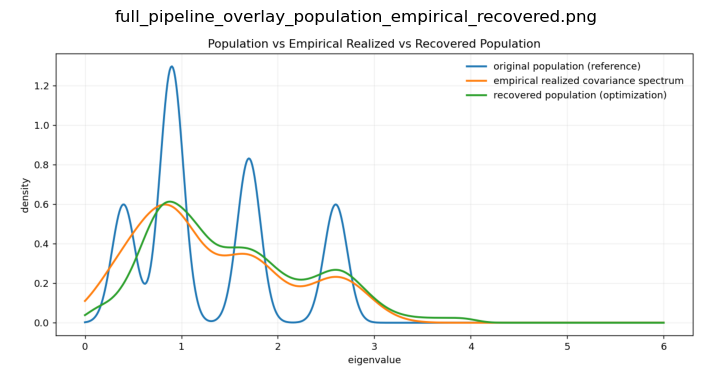

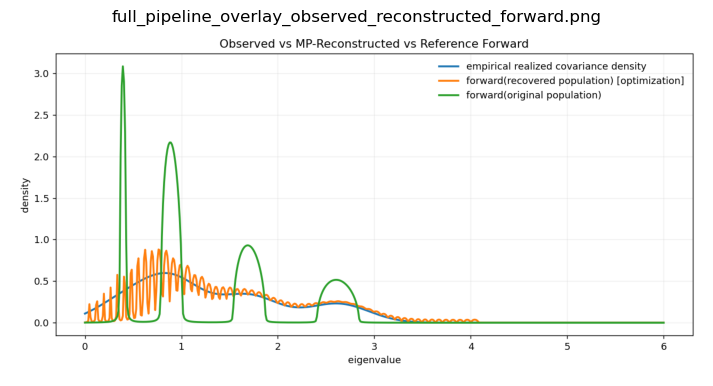

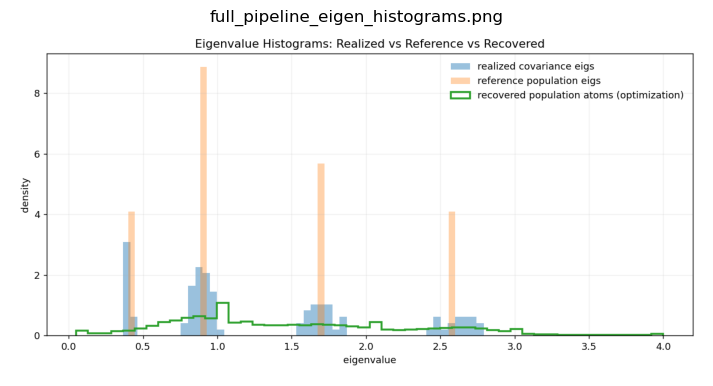

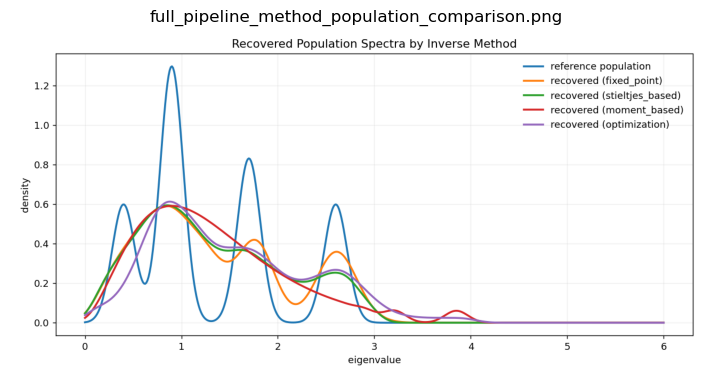

In [12]:
fig_paths = [
    out_dir / 'full_pipeline_overlay_population_empirical_recovered.png',
    out_dir / 'full_pipeline_overlay_observed_reconstructed_forward.png',
    out_dir / 'full_pipeline_eigen_histograms.png',
    out_dir / 'full_pipeline_method_population_comparison.png',
]

for p in fig_paths:
    if p.exists():
        img = mpimg.imread(p)
        plt.figure(figsize=(10, 4.5))
        plt.imshow(img)
        plt.title(p.name)
        plt.axis('off')
        plt.show()


## Interpretation Checklist

- Compare `population_wasserstein_1` and `reconstruction_l2` jointly.
- Inspect whether best method is stable across nearby config choices.
- For piecewise models, remember reference law is based on integrated covariance over time.
